# 10 mV voltage step analysis

Membrane resistance ($R_m$) and series resistance ($R_s$) are extracted from voltage-clamp recordings (19 sweeps, 300 ms, 10 kHz, holding potential −100 mV) using this custom Python script (pyabf; Harden & Bhatt). A 50 ms pre-step epoch at 0 mV served as baseline, followed by a 50 ms absolute voltage step of +10 mV. Baseline-corrected peak transient and steady-state currents were averaged across sweeps and used to derive $R_s$ and $R_m$ via Ohm's law:

$$R_s = \frac{10}{(I_{peak} - I_{ss}) + I_{ss}} \times 1000 \qquad R_{m+s} = \frac{10}{I_{ss}} \times 1000 \qquad R_m = R_{m+s} - R_s$$

where current is in pA and resistance in MΩ.


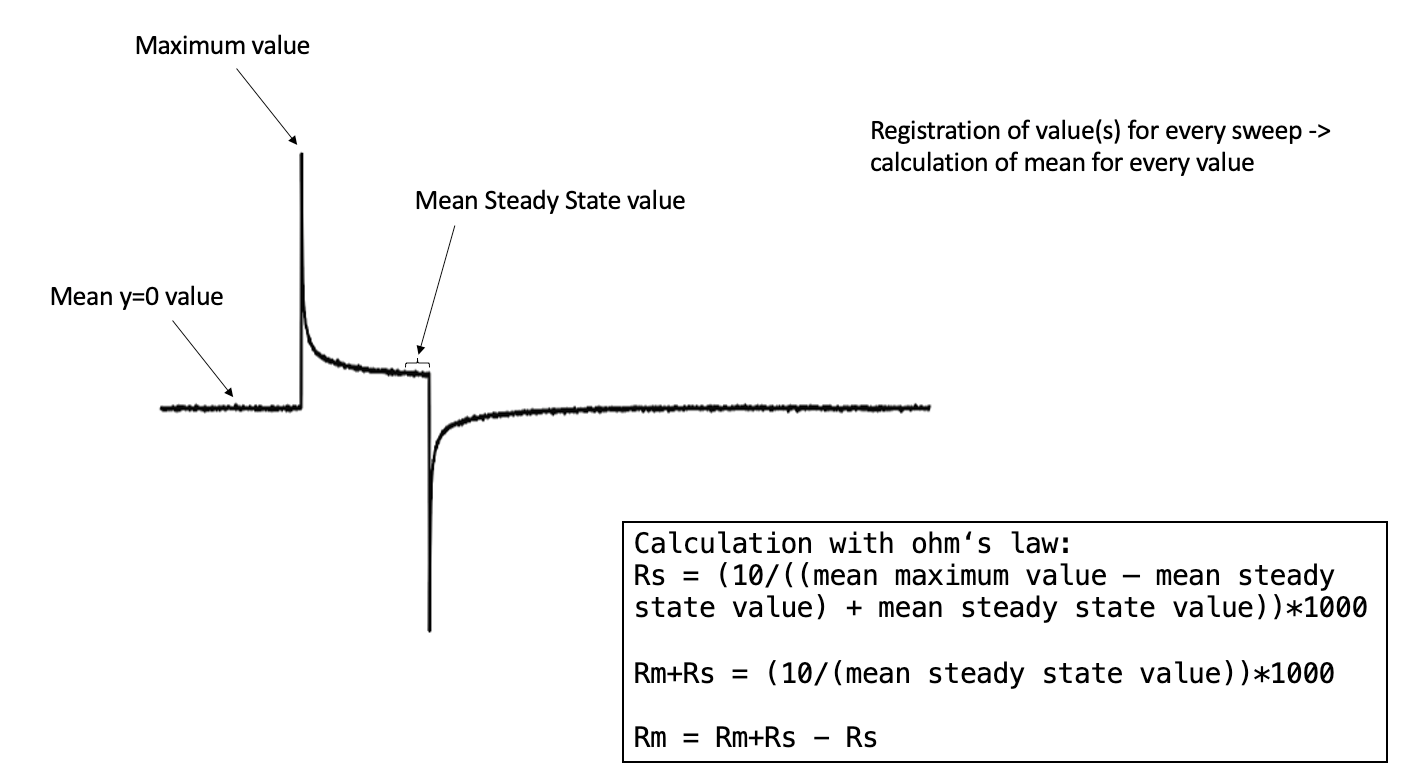

In [ ]:
import pyabf
import numpy as np
import pandas as pd
import os

In [ ]:
# Path to folder containing .abf files
directory = r"directory_path"
 
file_names = [f for f in os.listdir(directory) if f.endswith('.abf')]
 
files_list, Rm_list, Rs_list = [], [], []
 
for file in file_names:
    file_path = os.path.join(directory, file)
    abf = pyabf.ABF(file_path)
 
    max_values          = []
    baseline_values     = []
    steady_state_values = []
 
    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep)
 
        # Peak transient current across the full sweep (occurs at Epoch B onset, ~50 ms)
        max_values.append(max(abf.sweepY))
 
        # Epoch A (0–50 ms): baseline current at 0 mV command, before the voltage step
        for i in range(abf.sweepPointCount):
            if 0 <= abf.sweepX[i] <= 0.05:
                baseline_values.append(abf.sweepY[i])
 
        # Epoch B end (95–103 ms): steady-state current near end of 10 mV step (50–100 ms)
        for i in range(abf.sweepPointCount):
            if 0.095 <= abf.sweepX[i] <= 0.103:
                steady_state_values.append(abf.sweepY[i])
 
    # Baseline-correct peak and steady-state currents (averaged across sweeps)
    mean_baseline_value   = np.mean(baseline_values)
    mean_max              = -mean_baseline_value + np.mean(max_values)
    mean_steady_state_values = -mean_baseline_value + np.mean(steady_state_values)
 
    # Ohm's law: R = V/I; 10 mV step, current in pA → ×1000 converts GΩ to MΩ
    Rs       = (10 / ((mean_max - mean_steady_state_values) + mean_steady_state_values)) * 1000
    RmplusRs = (10 / mean_steady_state_values) * 1000
    Rm       = RmplusRs - Rs
 
    files_list.append(file)
    Rm_list.append(Rm)
    Rs_list.append(Rs)
 
df = pd.DataFrame({'File': files_list, 'Rm': Rm_list, 'Rs': Rs_list})
df.to_excel('Rm_Rs.xlsx', index=False)
